# Unsupervised
Here is where we will do the unsupervised clustering analysis of the data to find the specific different play styles

In [24]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
print('imports done!')

imports done!


In [25]:
# helper functions

In [26]:
# pull in the data frame
df = pd.read_csv('./df_final.csv')

# show
df

,Unnamed: 0,Age,G,GS,MP_x,FG,FGA,FG%,3P,3PA,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Player,Team
0,0,26.0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,...,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9,Shai Gilgeous-Alexander,OKC
1,1,30.0,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,...,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6,Giannis Antetokounmpo,MIL
2,2,29.0,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,...,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8,Nikola Jokić,DEN
3,3,25.0,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,...,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8,Luka Dončić,DAL
4,4,25.0,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,...,2.0,1.4,3.4,0.164,5.5,1.1,6.5,2.1,Luka Dončić,LAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,620,23.0,20.0,0.0,6.3,0.6,1.7,0.324,0.1,0.9,...,-0.2,0.1,-0.1,-0.031,-7.7,-0.8,-8.5,-0.2,Spencer Jones,DEN
547,627,26.0,33.0,2.0,7.0,0.4,1.6,0.245,0.2,1.0,...,-0.7,0.4,-0.3,-0.057,-8.4,0.3,-8.1,-0.4,Xavier Tillman Sr.,BOS
548,628,23.0,12.0,0.0,7.3,0.4,1.7,0.250,0.0,0.8,...,-0.2,0.1,-0.1,-0.082,-7.8,-1.9,-9.7,-0.2,Luke Travers,CLE
549,630,25.0,19.0,0.0,5.3,0.4,1.1,0.381,0.1,0.5,...,-0.1,0.1,0.0,-0.007,-7.1,1.7,-5.4,-0.1,Justin Minaya,POR


In [27]:
### make per minutes rates
dict_perminute = {'2PA_per_min': df['2PA'] / df['MP_x'],
                 '3PA_per_min': df['3PA'] / df['MP_x'],
                 'FTA_per_min': df['FTA'] / df['MP_x'],
                 'PTS_per_min': df['PTS'] / df['MP_x'],
                 'AST_per_min': df['AST'] / df['MP_x'],
                 'ORB_per_min': df['ORB'] / df['MP_x'],
                 'DRB_per_min': df['DRB'] / df['MP_x'],
                 'STL_per_min': df['STL'] / df['MP_x'],
                 'BLK_per_min': df['BLK'] / df['MP_x'],
                 '3PAr': df['3PAr'],
                 'USG%': df['USG%'],
                 'FTr': df['FTr'],
                 }

df_perminute = pd.DataFrame(dict_perminute)

df_perminute

,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,BLK_per_min,3PAr,USG%,FTr
0,0.470760,0.166667,0.257310,0.956140,0.187135,0.026316,0.119883,0.049708,0.029240,0.263,34.8,0.404
1,0.546784,0.026316,0.309942,0.888889,0.190058,0.064327,0.283626,0.026316,0.035088,0.048,35.2,0.536
2,0.403270,0.128065,0.174387,0.806540,0.277929,0.079019,0.269755,0.049046,0.016349,0.243,29.5,0.331
3,0.322129,0.268908,0.184874,0.787115,0.218487,0.019608,0.212885,0.056022,0.011204,0.455,33.1,0.313
4,0.296296,0.273504,0.253561,0.803419,0.213675,0.025641,0.205128,0.045584,0.011396,0.481,34.5,0.445
...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.142857,0.142857,0.031746,0.206349,0.047619,0.063492,0.079365,0.047619,0.047619,0.500,13.7,0.088
547,0.085714,0.142857,0.014286,0.142857,0.028571,0.042857,0.142857,0.042857,0.028571,0.604,13.1,0.075
548,0.123288,0.109589,0.027397,0.136986,0.095890,0.095890,0.136986,0.013699,0.013699,0.450,13.9,0.100
549,0.113208,0.094340,0.018868,0.169811,0.075472,0.056604,0.056604,0.056604,0.018868,0.476,11.1,0.095


In [28]:
#### Standardize the data
#get the colnames
colnames = df_perminute.columns

# init the scalar
scalar = StandardScaler()
# fit the scalar and transform
df_scaled = pd.DataFrame(
    scalar.fit_transform(df_perminute),
    columns=colnames,
    index=df_perminute.index
)

# show
df_scaled

,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,BLK_per_min,3PAr,USG%,FTr
0,3.112213,0.195823,3.644994,3.719816,1.548331,-0.652030,-0.256552,0.925817,0.503627,-0.891301,2.973228,1.493197
1,3.978070,-1.695639,4.742586,3.242835,1.602019,0.439354,2.769104,-0.589964,0.843082,-1.997466,3.047345,2.655312
2,2.343539,-0.324394,1.915697,2.658773,3.215444,0.861175,2.512794,0.882966,-0.244655,-0.994200,1.991175,0.850512
3,1.419396,1.573689,2.134396,2.521004,2.124013,-0.844627,1.461951,1.335014,-0.543265,0.096531,2.658230,0.692041
4,1.125180,1.635637,3.566818,2.636640,2.035654,-0.671403,1.318618,0.658612,-0.532148,0.230300,2.917640,1.854157
...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.622393,-0.125050,-1.058972,-1.598071,-1.013363,0.415367,-1.005247,0.790479,1.570487,0.328054,-0.936452,-1.288837
547,-1.273214,-0.125050,-1.423094,-2.048388,-1.363103,-0.177098,0.167966,0.481909,0.464832,0.863130,-1.047628,-1.403288
548,-0.845277,-0.573394,-1.149663,-2.090027,-0.127035,1.345581,0.059484,-1.407551,-0.398488,0.070806,-0.899393,-1.183190
549,-0.960083,-0.778905,-1.327535,-1.857216,-0.501951,0.217592,-1.425833,1.372686,-0.098426,0.204575,-1.418214,-1.227210


### Finding ideal K

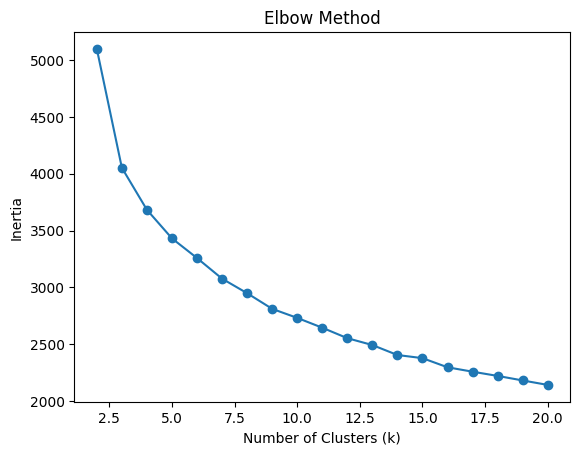

In [29]:
inertia = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig('../03_progress/plots/KMeans_elbow.png', bbox_inches='tight', dpi=300)
plt.show()

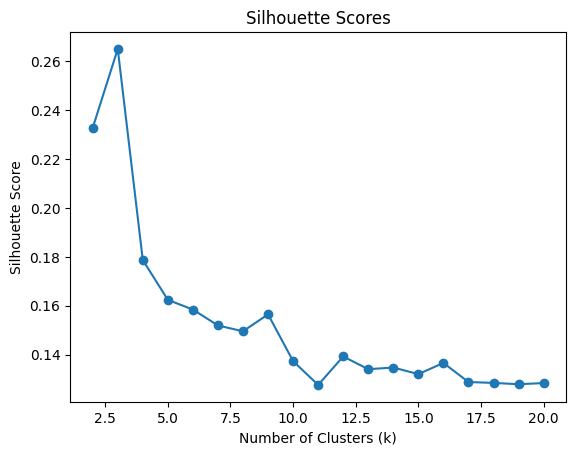

In [30]:
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.savefig('../03_progress/plots/KMeans_Silhouette.png', bbox_inches='tight', dpi=300)
plt.show()

In [31]:
sil_scores

[0.23273275963756518,
 0.2650751262846938,
 0.17867409626613168,
 0.16238405124250915,
 0.1584166229477558,
 0.151904761592454,
 0.14951691208762904,
 0.1564535368372207,
 0.1373132102405295,
 0.12757361653531957,
 0.1392109821231362,
 0.13401314609354276,
 0.1346847723598,
 0.13200113413502057,
 0.13656922324070384,
 0.12876839811206828,
 0.1283905428528405,
 0.12786373245453056,
 0.12833553982039658]

In [32]:
# I like doing 9 clusters

### Clustering

In [33]:
feature_cols = [
    '2PA_per_min', '3PA_per_min', 'FTA_per_min', 'PTS_per_min',
    'AST_per_min', 'ORB_per_min', 'DRB_per_min', 'STL_per_min',
    'BLK_per_min', '3PAr', 'USG%', 'FTr'
]

X = df_scaled[feature_cols].copy()

kmeans_9 = KMeans(n_clusters=9, random_state=42, n_init=10)
df_scaled['cluster_9'] = kmeans_9.fit_predict(X)

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scaled['cluster_3'] = kmeans_3.fit_predict(X)

df_perminute['cluster_3'] = df_scaled['cluster_3']
df_perminute['cluster_9'] = df_scaled['cluster_9']

df['cluster_3'] = df_scaled['cluster_3']
df['cluster_9'] = df_scaled['cluster_9']

cluster_summary_3 = df_perminute.groupby('cluster_3').mean(numeric_only=True)
cluster_summary_9 = df_perminute.groupby('cluster_9').mean(numeric_only=True)

In [34]:
cluster_summary_3

,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,BLK_per_min,3PAr,USG%,FTr,cluster_9
cluster_3,,,,,,,,,,,,,
0,0.292193,0.182564,0.140975,0.614543,0.148305,0.036049,0.134506,0.036056,0.016368,0.384244,26.145802,0.299733,3.221374
1,0.146031,0.170345,0.055441,0.370667,0.093503,0.038047,0.112023,0.036374,0.015745,0.539744,16.508013,0.178205,4.179487
2,0.231349,0.062626,0.089872,0.386073,0.074506,0.096480,0.195688,0.031895,0.039572,0.200287,16.275926,0.317463,5.000000


In [35]:
print(cluster_summary_3.to_markdown())

|   cluster_3 |   2PA_per_min |   3PA_per_min |   FTA_per_min |   PTS_per_min |   AST_per_min |   ORB_per_min |   DRB_per_min |   STL_per_min |   BLK_per_min |     3PAr |    USG% |      FTr |   cluster_9 |
|------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|---------:|--------:|---------:|------------:|
|           0 |      0.292193 |     0.182564  |     0.140975  |      0.614543 |     0.148305  |     0.0360494 |      0.134506 |     0.0360557 |     0.0163681 | 0.384244 | 26.1458 | 0.299733 |     3.22137 |
|           1 |      0.146031 |     0.170345  |     0.0554415 |      0.370667 |     0.0935034 |     0.038047  |      0.112023 |     0.0363738 |     0.0157453 | 0.539744 | 16.508  | 0.178205 |     4.17949 |
|           2 |      0.231349 |     0.0626256 |     0.0898723 |      0.386073 |     0.0745063 |     0.0964797 |      0.195688 |     0.0318947 |     0.0395719 | 0.200287 | 16.27

In [36]:
cluster_map = {
    0: 'High Volume Offensive Stars',
    1: 'Balanced Role Players',
    2: 'Rebounding Bigs',
}
df['cluster_3_label'] = df['cluster_3'].map(cluster_map)

In [37]:
cluster_summary_9

,2PA_per_min,3PA_per_min,FTA_per_min,PTS_per_min,AST_per_min,ORB_per_min,DRB_per_min,STL_per_min,BLK_per_min,3PAr,USG%,FTr,cluster_3
cluster_9,,,,,,,,,,,,,
0,0.377979,0.098907,0.182707,0.658725,0.127938,0.080408,0.207429,0.033824,0.029933,0.206407,26.918519,0.383444,0.518519
1,0.120581,0.232788,0.046503,0.422392,0.083445,0.026088,0.101460,0.028618,0.010938,0.662512,17.663095,0.132060,1.000000
2,0.200932,0.198667,0.085465,0.486833,0.068524,0.068970,0.193376,0.028127,0.050500,0.500733,20.606667,0.217933,1.266667
3,0.282341,0.207708,0.136311,0.631281,0.148660,0.026790,0.118913,0.033597,0.011938,0.422729,26.815294,0.280847,0.000000
4,0.107153,0.143809,0.037588,0.278406,0.068297,0.051908,0.120508,0.037918,0.018605,0.578222,13.111111,0.151383,1.012346
5,0.193316,0.125025,0.086305,0.396313,0.080414,0.047105,0.129884,0.033049,0.017202,0.387989,17.179310,0.276805,1.195402
6,0.236354,0.028276,0.083444,0.364301,0.070457,0.109270,0.206492,0.026956,0.043985,0.104583,14.860000,0.327800,2.000000
7,0.175122,0.130883,0.081189,0.349849,0.099443,0.058987,0.120722,0.073618,0.019222,0.429107,16.842857,0.277571,1.142857
8,0.201174,0.146379,0.067374,0.400503,0.173223,0.025996,0.099171,0.041659,0.012940,0.424754,18.921739,0.195812,0.782609


In [38]:
print(cluster_summary_9.to_markdown())

|   cluster_9 |   2PA_per_min |   3PA_per_min |   FTA_per_min |   PTS_per_min |   AST_per_min |   ORB_per_min |   DRB_per_min |   STL_per_min |   BLK_per_min |     3PAr |    USG% |      FTr |   cluster_3 |
|------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|--------------:|---------:|--------:|---------:|------------:|
|           0 |      0.377979 |     0.0989073 |     0.182707  |      0.658725 |     0.127938  |     0.0804081 |     0.207429  |     0.0338243 |     0.0299327 | 0.206407 | 26.9185 | 0.383444 |    0.518519 |
|           1 |      0.120581 |     0.232788  |     0.0465033 |      0.422392 |     0.0834449 |     0.0260884 |     0.10146   |     0.0286183 |     0.0109377 | 0.662512 | 17.6631 | 0.13206  |    1        |
|           2 |      0.200932 |     0.198667  |     0.0854652 |      0.486833 |     0.0685242 |     0.0689698 |     0.193376  |     0.0281275 |     0.0505004 | 0.500733 | 20.60

In [39]:
cluster_map = {
    0: 'Interior Scoring Stars',
    1: 'High Volume Three Point Specialists',
    2: 'Stretch Bigs',
    3: 'Primary Offensive Engines',
    4: 'Low Usage Floor Spacers',
    5: 'Balanced Role Players',
    6: 'Traditional Interior Bigs',
    7: 'Defensive Guards',
    8: 'Secondary Playmakers'
}
df['cluster_9_label'] = df['cluster_9'].map(cluster_map)

### PCA Plots

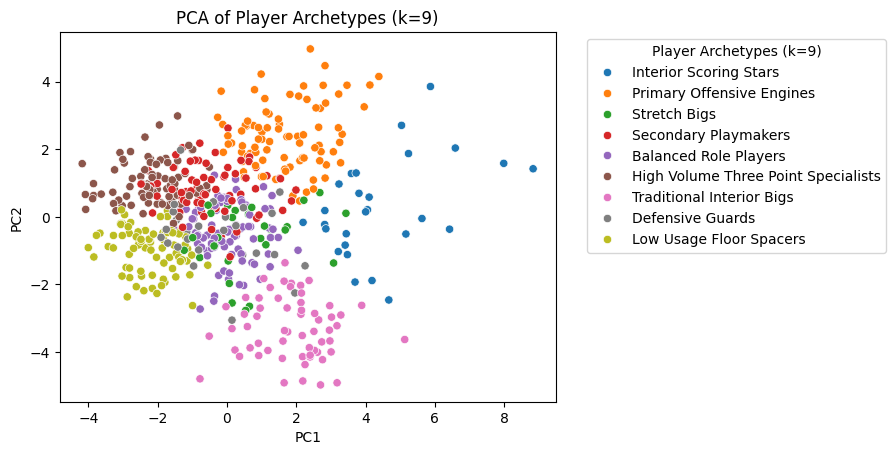

In [40]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.drop(['cluster_3', 'cluster_9'], axis=1))

sns.scatterplot(
    x=df_pca[:, 0],
    y=df_pca[:, 1],
    hue=df['cluster_9_label']
)

plt.title("PCA of Player Archetypes (k=9)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    title="Player Archetypes (k=9)",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.savefig('../03_progress/plots/PCA_k=9.png', bbox_inches='tight', dpi=300)
plt.show()

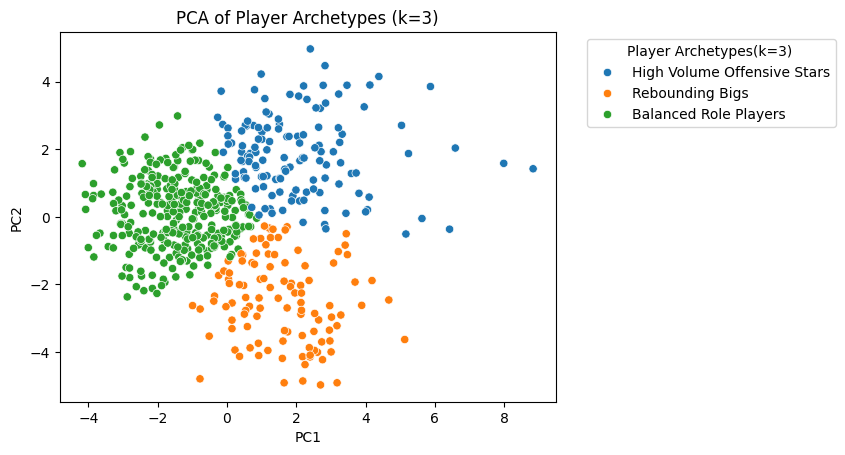

In [41]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled.drop(['cluster_3', 'cluster_9'], axis=1))

sns.scatterplot(
    x=df_pca[:, 0],
    y=df_pca[:, 1],
    hue=df['cluster_3_label']
)

plt.title("PCA of Player Archetypes (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    title="Player Archetypes(k=3) ",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.savefig('../03_progress/plots/PCA_k=3.png', bbox_inches='tight', dpi=300)
plt.show()

### Save the df with the labels

In [42]:
# take a looks
df

,Unnamed: 0,Age,G,GS,MP_x,FG,FGA,FG%,3P,3PA,...,OBPM,DBPM,BPM,VORP,Player,Team,cluster_3,cluster_9,cluster_3_label,cluster_9_label
0,0,26.0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,...,8.9,2.6,11.5,8.9,Shai Gilgeous-Alexander,OKC,0,0,High Volume Offensive Stars,Interior Scoring Stars
1,1,30.0,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,...,6.9,2.5,9.5,6.6,Giannis Antetokounmpo,MIL,0,0,High Volume Offensive Stars,Interior Scoring Stars
2,2,29.0,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,...,9.9,3.3,13.3,9.8,Nikola Jokić,DEN,0,0,High Volume Offensive Stars,Interior Scoring Stars
3,3,25.0,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,...,5.5,1.4,6.9,1.8,Luka Dončić,DAL,0,3,High Volume Offensive Stars,Primary Offensive Engines
4,4,25.0,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,...,5.5,1.1,6.5,2.1,Luka Dončić,LAL,0,3,High Volume Offensive Stars,Primary Offensive Engines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,620,23.0,20.0,0.0,6.3,0.6,1.7,0.324,0.1,0.9,...,-7.7,-0.8,-8.5,-0.2,Spencer Jones,DEN,1,4,Balanced Role Players,Low Usage Floor Spacers
547,627,26.0,33.0,2.0,7.0,0.4,1.6,0.245,0.2,1.0,...,-8.4,0.3,-8.1,-0.4,Xavier Tillman Sr.,BOS,1,4,Balanced Role Players,Low Usage Floor Spacers
548,628,23.0,12.0,0.0,7.3,0.4,1.7,0.250,0.0,0.8,...,-7.8,-1.9,-9.7,-0.2,Luke Travers,CLE,1,4,Balanced Role Players,Low Usage Floor Spacers
549,630,25.0,19.0,0.0,5.3,0.4,1.1,0.381,0.1,0.5,...,-7.1,1.7,-5.4,-0.1,Justin Minaya,POR,1,4,Balanced Role Players,Low Usage Floor Spacers


In [43]:
# save the data frame
df.to_csv('./df_labels.csv')